Random Forest Classifier for TAU 2019 Acoustic Scenes

- Loading the saved splits and metadata
- Reusing cached features from logmel_stats_all.npz
- Hyperparameter tuning for RF with cross-validation
- Saving CV results to rf_cv_results.csv
- Training a final RF model and saving it to rf_model.joblib
- Evaluation on the test set + confusion matrix and RF feature importances.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import joblib

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import StratifiedKFold

sns.set(style='whitegrid')

SR = 22050
RANDOM_STATE = 42

def read_meta(path: str = 'meta.csv') -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError('meta.csv not found')
    meta = pd.read_csv(path, sep='\t', quotechar='"')
    required = ['filename', 'scene_label', 'identifier']
    for c in required:
        if c not in meta:
            raise ValueError(f'Missing {c} in meta')
    meta['filepath'] = meta['filename'].apply(lambda f: os.path.join('.', f))
    return meta

def logmel_stats_from_path(
    path: str,
    sr: int = SR,
    n_mels: int = 128,
    hop_length: int = 1024,
    fmin: int = 50,
    fmax=None,
    use_zscore: bool = True,
    percentiles=(10, 90),
):
    y, sr = librosa.load(path, sr=sr, mono=True)
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=n_mels,
        hop_length=hop_length, fmin=fmin, fmax=fmax, power=2.0,
    )
    L = librosa.power_to_db(S, ref=np.max).astype(np.float32)
    if use_zscore:
        mu = float(L.mean())
        sd = float(L.std() + 1e-8)
        L = (L - mu) / sd
    mu = L.mean(axis=1)
    sd = L.std(axis=1)
    p_lo, p_hi = np.percentile(L, percentiles[0], axis=1), np.percentile(L, percentiles[1], axis=1)
    return np.concatenate([mu, sd, p_lo, p_hi]).astype(np.float32)

def build_logmel_stats_matrix(paths, **kwargs) -> np.ndarray:
    feats = [logmel_stats_from_path(p, **kwargs) for p in paths]
    return np.vstack(feats)


In [ ]:
# load split
splits = np.load('splits_tau2019_grouped.npz')
tr_idx, va_idx, te_idx = splits['tr_idx'], splits['va_idx'], splits['te_idx']
meta = read_meta('meta.csv')
filepaths = meta['filepath'].tolist()
labels = meta['scene_label'].to_numpy()

le = LabelEncoder()
y_all = le.fit_transform(labels)
class_names = le.classes_
class_names


array(['airport', 'bus', 'metro', 'metro_station', 'park',
       'public_square', 'shopping_mall', 'street_pedestrian',
       'street_traffic', 'tram'], dtype=object)

In [ ]:
# build feature
if os.path.exists('logmel_stats_all.npz'):
    data = np.load('logmel_stats_all.npz')
    X_all = data['X_all']
    print('Loaded cached log-mel features from logmel_stats_all.npz')
else:
    X_all = build_logmel_stats_matrix(
        filepaths,
        sr=SR,
        n_mels=128,
        hop_length=1024,
        fmin=50,
        fmax=None,
        use_zscore=True,
        percentiles=(10, 90),
    )
    np.savez('logmel_stats_all.npz', X_all=X_all)
    print('Computed and cached log-mel features to logmel_stats_all.npz')
print('Feature matrix shape:', X_all.shape)

X_tr, X_va, X_te = X_all[tr_idx], X_all[va_idx], X_all[te_idx]
y_tr, y_va, y_te = y_all[tr_idx], y_all[va_idx], y_all[te_idx]
X_tr.shape, X_va.shape, X_te.shape


Loaded cached log-mel features from logmel_stats_all.npz
Feature matrix shape: (14400, 512)


((9309, 512), (2347, 512), (2744, 512))

In [ ]:
# hyperparameters
param_space_rf = [
    {'n_estimators': n, 'max_depth': d, 'max_features': mf}
    for n in [200, 300]
    for d in [None, 20, 40]
    for mf in ['sqrt', 0.5]
]

best_rf_params = None
best_rf_cv = -np.inf
cv_rows = []
for params in param_space_rf:
    rf = RandomForestClassifier(
        n_estimators=params['n_estimators'],
        max_depth=params['max_depth'],
        max_features=params['max_features'],
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    cv_accs = []
    for tr_fold, va_fold in skf.split(X_tr, y_tr):
        rf.fit(X_tr[tr_fold], y_tr[tr_fold])
        y_pred_fold = rf.predict(X_tr[va_fold])
        cv_accs.append(accuracy_score(y_tr[va_fold], y_pred_fold))
    mean_cv = float(np.mean(cv_accs))
    std_cv = float(np.std(cv_accs))
    print('Params:', params, 'CV acc:', mean_cv)
    cv_rows.append({'n_estimators': params['n_estimators'],
                    'max_depth': params['max_depth'],
                    'max_features': params['max_features'],
                    'mean_acc': mean_cv,
                    'std_acc': std_cv})
    if mean_cv > best_rf_cv:
        best_rf_cv = mean_cv
        best_rf_params = params

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv('rf_cv_results.csv', index=False)
print('Saved CV results to rf_cv_results.csv')

print('Best RF params:', best_rf_params)
print('Best RF CV accuracy:', best_rf_cv)


Params: {'n_estimators': 200, 'max_depth': None, 'max_features': 'sqrt'} CV acc: 0.8026631213021422
Params: {'n_estimators': 200, 'max_depth': None, 'max_features': 0.5} CV acc: 0.7853678104064953
Params: {'n_estimators': 200, 'max_depth': 20, 'max_features': 'sqrt'} CV acc: 0.8012667732892529
Params: {'n_estimators': 200, 'max_depth': 20, 'max_features': 0.5} CV acc: 0.784293003946113
Params: {'n_estimators': 200, 'max_depth': 40, 'max_features': 'sqrt'} CV acc: 0.8026631790191683
Params: {'n_estimators': 200, 'max_depth': 40, 'max_features': 0.5} CV acc: 0.7855826331777089
Params: {'n_estimators': 300, 'max_depth': None, 'max_features': 'sqrt'} CV acc: 0.8033074741817312
Params: {'n_estimators': 300, 'max_depth': None, 'max_features': 0.5} CV acc: 0.7908464836767591
Params: {'n_estimators': 300, 'max_depth': 20, 'max_features': 'sqrt'} CV acc: 0.8049194530042001
Params: {'n_estimators': 300, 'max_depth': 20, 'max_features': 0.5} CV acc: 0.7892343317032121
Params: {'n_estimators': 300

In [ ]:
# train eval
rf_final = RandomForestClassifier(
    n_estimators=best_rf_params['n_estimators'],
    max_depth=best_rf_params['max_depth'],
    max_features=best_rf_params['max_features'],
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
X_train_full = np.vstack([X_tr, X_va])
y_train_full = np.concatenate([y_tr, y_va])
rf_final.fit(X_train_full, y_train_full)
joblib.dump(rf_final, 'rf_model.joblib')
print('Saved trained RF model to rf_model.joblib')

y_pred_rf_te = rf_final.predict(X_te)
print(classification_report(y_te, y_pred_rf_te, target_names=class_names))


Saved trained RF model to rf_model.joblib
                   precision    recall  f1-score   support

          airport       0.36      0.43      0.39       192
              bus       0.56      0.57      0.56       341
            metro       0.57      0.45      0.50       333
    metro_station       0.44      0.47      0.45       307
             park       0.86      0.76      0.81       403
    public_square       0.43      0.40      0.41       211
    shopping_mall       0.57      0.64      0.60       229
street_pedestrian       0.45      0.43      0.44       282
   street_traffic       0.50      0.79      0.62        97
             tram       0.61      0.62      0.61       349

         accuracy                           0.55      2744
        macro avg       0.54      0.56      0.54      2744
     weighted avg       0.56      0.55      0.56      2744



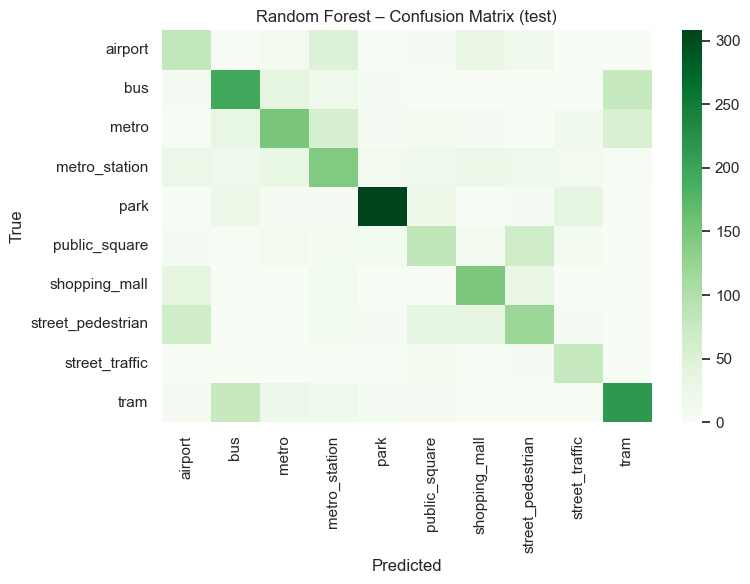

In [ ]:
# confusion matrix
cm_rf = confusion_matrix(y_te, y_pred_rf_te)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=False, cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Random Forest – Confusion Matrix')
plt.tight_layout()
plt.show()


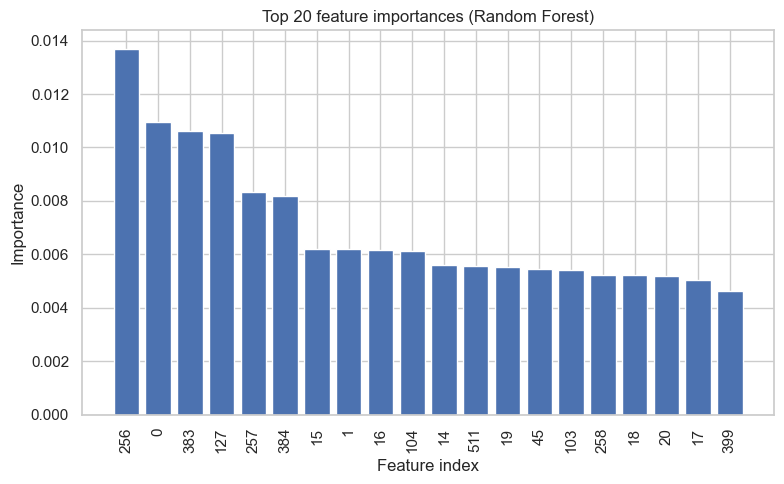

In [ ]:
# feature importances
importances = rf_final.feature_importances_
indices = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(8, 5))
plt.bar(range(len(indices)), importances[indices])
plt.xticks(range(len(indices)), indices, rotation=90)
plt.title('Top 20 feature importances (Random Forest)')
plt.xlabel('Feature index')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()
